In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install timm
!pip install albumentations
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6be9cd749ab96a59e69dc64312378e44a082e9df2549d4928f283eea2d9e3179
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Unzip Dataset

In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/Emotion-XAI/data/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/fer2013")

Check Dataset Structure

In [5]:
import os

dataset_path = "/content/fer2013/train"

print(os.listdir(dataset_path))

['fear', 'disgust', 'happy', 'surprise', 'sad', 'neutral', 'angry']


Visualize Images

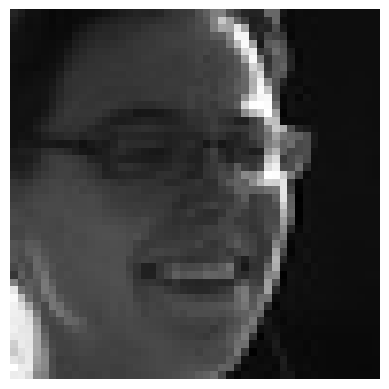

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os

emotion = "happy"

folder = f"/content/fer2013/train/{emotion}"

img_path = os.path.join(folder, os.listdir(folder)[0])

img = Image.open(img_path)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

Count Images Per Class

In [7]:
import os

train_dir = "/content/fer2013/train"

for cls in os.listdir(train_dir):
    cnt = len(os.listdir(os.path.join(train_dir, cls)))
    print(cls, cnt)

fear 4097
disgust 436
happy 7215
surprise 3171
sad 4830
neutral 4965
angry 3995


Create Data Augmentation Pipeline

In [26]:
from torchvision import transforms

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Load Dataset

In [9]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    "/content/fer2013/train",
    transform=train_transform
)

test_dataset = ImageFolder(
    "/content/fer2013/test",
    transform=val_transform
)

In [10]:
print(len(train_dataset))
print(len(test_dataset))

28709
7178


Create weights:

In [16]:
import torch

class_counts = [
    3995,  # angry
    436,   # disgust
    4097,  # fear
    7215,  # happy
    4965,  # neutral
    4830,  # sad
    3171   # surprise
]

weights = [1/x for x in class_counts]

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

Create DataLoader

In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Verify Data Pipeline

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
print(train_dataset.class_to_idx)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Import Libraries

In [15]:
import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


Load EfficientNet-B0

In [15]:
model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=7
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [16]:
print(model)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

Freeze Backbone

In [17]:
for param in model.parameters():
    param.requires_grad = False

Enable classifier:

In [18]:
for param in model.classifier.parameters():
    param.requires_grad = True

Check trainable params:

In [19]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

8967

In [20]:
#Loss Function for now
criterion = nn.CrossEntropyLoss()

Optimizer

In [45]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

Training Function

In [46]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

Validation Function

In [47]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total

Train for 5 Epochs

In [24]:
best_acc = 0

for epoch in range(5):

    loss = train_one_epoch(model, train_loader)

    acc = evaluate(model, test_loader)

    print(
        f"Epoch {epoch+1} | Loss {loss:.4f} | Accuracy {acc:.2f}%"
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Emotion-XAI/models/best_b0.pth"
        )

Epoch 1 | Loss 2.3637 | Accuracy 31.11%
Epoch 2 | Loss 1.9003 | Accuracy 33.94%
Epoch 3 | Loss 1.7397 | Accuracy 36.12%
Epoch 4 | Loss 1.6572 | Accuracy 36.68%
Epoch 5 | Loss 1.5900 | Accuracy 38.94%


In [48]:
for param in model.parameters():
    param.requires_grad = True

In [49]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

4016515

In [76]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

In [52]:
best_acc = 0

for epoch in range(15):

    loss = train_one_epoch(model, train_loader)

    acc = evaluate(model, test_loader)

    scheduler.step(acc)

    print(
        f"Epoch {epoch+1} | Loss {loss:.4f} | Acc {acc:.2f}%"
    )

    if acc > best_acc:

        best_acc = acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Emotion-XAI/models/best_b0_finetuned.pth"
        )

Epoch 1 | Loss 0.5005 | Acc 65.62%
Epoch 2 | Loss 0.4061 | Acc 67.32%
Epoch 3 | Loss 0.3308 | Acc 67.30%
Epoch 4 | Loss 0.2660 | Acc 68.31%
Epoch 5 | Loss 0.2283 | Acc 68.04%
Epoch 6 | Loss 0.1981 | Acc 67.15%
Epoch 7 | Loss 0.1734 | Acc 68.19%
Epoch 8 | Loss 0.1066 | Acc 69.14%
Epoch 9 | Loss 0.0872 | Acc 68.97%
Epoch 10 | Loss 0.0797 | Acc 68.78%
Epoch 11 | Loss 0.0715 | Acc 68.79%
Epoch 12 | Loss 0.0567 | Acc 69.45%
Epoch 13 | Loss 0.0453 | Acc 69.43%
Epoch 14 | Loss 0.0442 | Acc 69.52%
Epoch 15 | Loss 0.0408 | Acc 69.32%


Report

In [53]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

       angry       0.60      0.61      0.61       958
     disgust       0.76      0.68      0.72       111
        fear       0.58      0.55      0.56      1024
       happy       0.87      0.87      0.87      1774
     neutral       0.64      0.64      0.64      1233
         sad       0.57      0.58      0.57      1247
    surprise       0.82      0.84      0.83       831

    accuracy                           0.69      7178
   macro avg       0.69      0.68      0.69      7178
weighted avg       0.69      0.69      0.69      7178



confusion matrix of base model

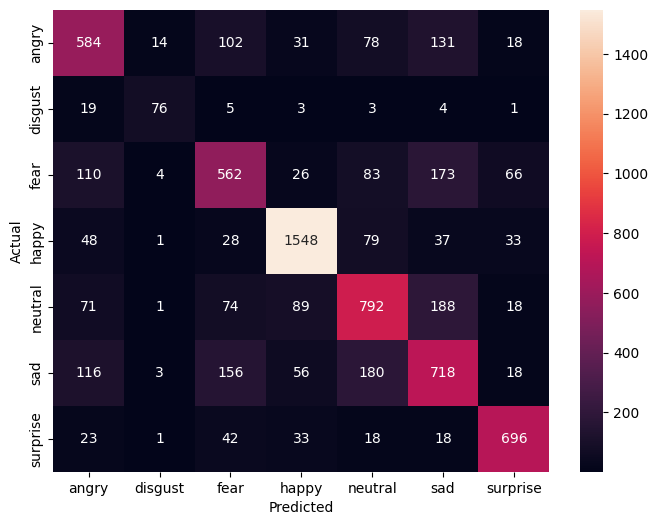

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
print(model)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

Create EfficientNet-B3 Model

In [18]:
import timm
import torch.nn as nn

model_b3 = timm.create_model(
    'efficientnet_b3',
    pretrained=True,
    num_classes=7
)

model_b3 = model_b3.to(device)

print("Model Loaded")

Model Loaded


Unfreeze Entire Model

In [19]:
for param in model_b3.parameters():
    param.requires_grad = True

print("All layers trainable")

All layers trainable


Weighted Loss

In [20]:
import torch

class_counts = [
    3995,
    436,
    4097,
    7215,
    4965,
    4830,
    3171
]

weights = [1/x for x in class_counts]

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

criterion_b3 = nn.CrossEntropyLoss(
    weight=weights
)

Optimizer

In [21]:
optimizer_b3 = torch.optim.AdamW(
    model_b3.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler

In [22]:
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3,
    mode='max',
    factor=0.5,
    patience=2
)

New Training Function

In [23]:
def train_one_epoch_b3(model, loader):

    model.train()

    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_b3.zero_grad()

        outputs = model(images)

        loss = criterion_b3(outputs, labels)

        loss.backward()

        optimizer_b3.step()

        running_loss += loss.item()

    return running_loss / len(loader)

Evaluation Function

In [24]:
def evaluate_b3(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total

Training Loop

In [ ]:
best_acc_b3 = 0

for epoch in range(10):

    loss = train_one_epoch_b3(
        model_b3,
        train_loader
    )

    acc = evaluate_b3(
        model_b3,
        test_loader
    )

    scheduler_b3.step(acc)

    print(
        f"Epoch {epoch+1} | Loss {loss:.4f} | Acc {acc:.2f}%"
    )

    if acc > best_acc_b3:

        best_acc_b3 = acc

        torch.save(
            model_b3.state_dict(),
            "/content/drive/MyDrive/Emotion-XAI/models/best_b3.pth"
        )

print(
    f"\nBest Accuracy = {best_acc_b3:.2f}%"
)

Epoch 1 | Loss 1.1724 | Acc 53.89%
Epoch 2 | Loss 0.9404 | Acc 63.29%
Epoch 3 | Loss 0.7846 | Acc 66.09%
Epoch 4 | Loss 0.6439 | Acc 66.62%
Epoch 5 | Loss 0.5116 | Acc 67.92%
Epoch 6 | Loss 0.3806 | Acc 67.90%
Epoch 7 | Loss 0.2882 | Acc 67.50%
Epoch 8 | Loss 0.2211 | Acc 68.00%
Epoch 9 | Loss 0.1796 | Acc 68.15%


Loding of b0 model

In [18]:
import torch
import timm

# Force CPU
device = torch.device("cpu")

# Create model
model = timm.create_model(
    'efficientnet_b0',
    pretrained=False,
    num_classes=7
)

# Load weights on CPU
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Emotion-XAI/models/best_b0_finetuned.pth",
        map_location=device
    )
)

# Move model to CPU
model = model.to(device)

# Evaluation mode
model.eval()

print("Model loaded successfully on CPU!")

Model loaded successfully on CPU!


In [19]:
!pip install grad-cam

In [20]:
print(model)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [21]:
model.conv_head

Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)

Imports

In [22]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

Class Names

In [23]:
class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

Select Test Image

In [28]:
import os
import random

emotion = "happy"   # change to angry, fear, sad, etc.

test_dir = f"/content/fer2013/test/{emotion}"

image_path = os.path.join(
    test_dir,
    random.choice(os.listdir(test_dir))
)

print(image_path)

/content/fer2013/test/happy/PrivateTest_31695363.jpg


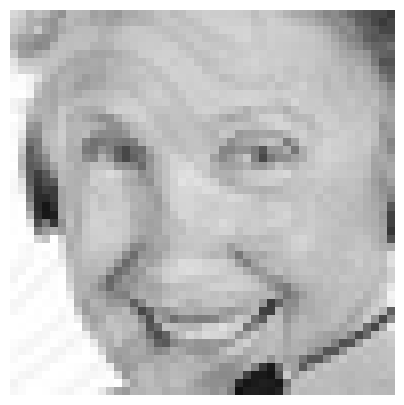

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.show()

Preprocess Image

In [31]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0)

In [32]:
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0)

model.eval()

with torch.no_grad():

    output = model(input_tensor)

    probs = torch.softmax(output, dim=1)

    pred_class = torch.argmax(probs, dim=1).item()

print("True Label:", emotion)
print("Predicted:", class_names[pred_class])
print(
    "Confidence:",
    round(probs[0][pred_class].item()*100,2),
    "%"
)

True Label: happy
Predicted: happy
Confidence: 99.61 %


Generate Grad-CAM

In [33]:
target_layers = [model.conv_head]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)

grayscale_cam = grayscale_cam[0]

Overlay Heatmap

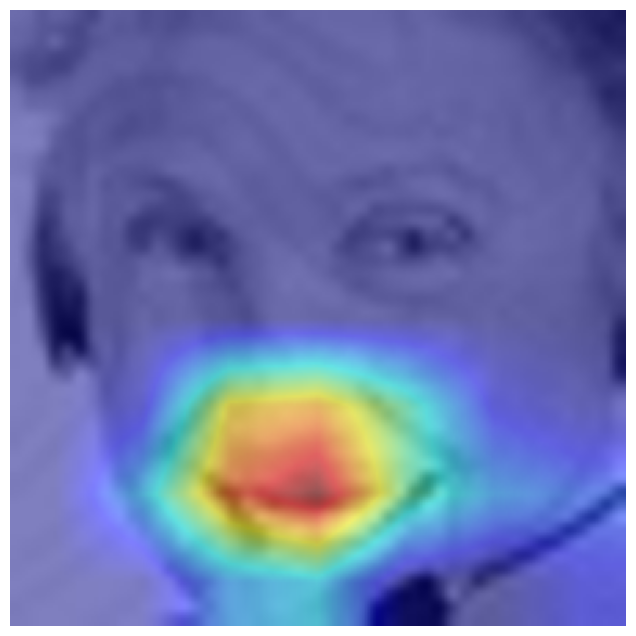

In [34]:
rgb_img = np.array(
    image.resize((224,224))
).astype(np.float32)/255.0

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))
plt.imshow(visualization)
plt.axis("off")
plt.show()

Show Original + Heatmap

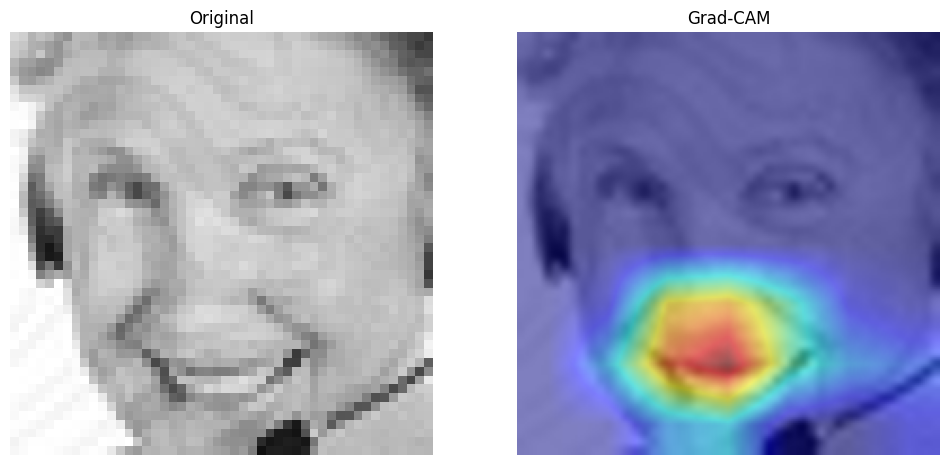

In [35]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(image)
ax[0].set_title("Original")

ax[1].imshow(visualization)
ax[1].set_title("Grad-CAM")

for a in ax:
    a.axis("off")

plt.show()

Top-3 Predictions

In [37]:
with torch.no_grad():

    output = model(input_tensor)

    probs = torch.softmax(output, dim=1)[0]

top_probs, top_indices = torch.topk(probs, 3)

print("Top 3 Predictions\n")

for p, idx in zip(top_probs, top_indices):

    print(
        f"{class_names[idx.item()]:<10}"
        f"{p.item()*100:.2f}%"
    )

Top 3 Predictions

happy     99.61%
fear      0.20%
neutral   0.14%


Confidence Bar Chart

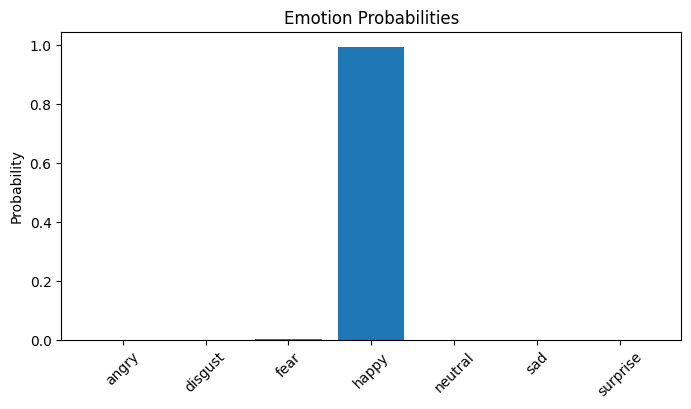

In [38]:
import matplotlib.pyplot as plt

with torch.no_grad():

    output = model(input_tensor)

    probs = torch.softmax(output, dim=1)[0].cpu().numpy()

plt.figure(figsize=(8,4))

plt.bar(class_names, probs)

plt.title("Emotion Probabilities")

plt.ylabel("Probability")

plt.xticks(rotation=45)

plt.show()

Automatic Explanation

In [39]:
predicted_emotion = class_names[pred_class]

explanations = {
    "happy":
    "The model focused primarily on the mouth and cheek regions, indicating a smiling facial expression.",

    "sad":
    "The model focused on the eyes and mouth regions, capturing features associated with sadness.",

    "angry":
    "The model focused on the eyebrows and eye region, which often indicate anger.",

    "fear":
    "The model focused on widened eyes and facial tension patterns associated with fear.",

    "surprise":
    "The model focused on the eyes and mouth, indicating an expression of surprise.",

    "neutral":
    "The model focused on the overall facial structure, indicating the absence of strong emotional cues.",

    "disgust":
    "The model focused on the nose and mouth regions, which are commonly associated with disgust."
}

print("\nExplanation:")
print(explanations[predicted_emotion])


Explanation:
The model focused primarily on the mouth and cheek regions, indicating a smiling facial expression.
